In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from methods.data_utils import load_data, pre_avg, \
    compute_returns, filter_day, summarize_data

DATA LOADING:
- Last ned data
- Hent data og lag 4 dataframes
- Set datetime som index
- Legg dataframes i et dictionary
- Print start, slutt, antall obs på hver

MARKETS: 
- EURUSD
- USDJPY
- USDZAR (South African Rand)
- XAUUSD (gold)

In [2]:
markets = ["EURUSD", "USDJPY", "USDZAR", "XAUUSD"]

eurusd = load_data(market = markets[0])
usdjpy = load_data(market = markets[1])
usdzar = load_data(market = markets[2])
xauusd = load_data(market = markets[3])

data = {"EURUSD": eurusd, 
        "USDJPY": usdjpy, 
        "USDZAR": usdzar, 
        "XAUUSD": xauusd}

for name, df in data.items():
    print(name)
    print("start:", df.index.min())
    print("end:", df.index.max())
    print("ticks:", len(df))
    print()

EURUSD
start: 2026-02-01 22:00:00.410000+00:00
end: 2026-02-27 21:59:59.033000+00:00
ticks: 1330124

USDJPY
start: 2026-02-01 22:00:01.917000+00:00
end: 2026-02-27 21:59:59.135000+00:00
ticks: 1994068

USDZAR
start: 2026-02-01 22:00:19.318000+00:00
end: 2026-02-27 21:59:59.090000+00:00
ticks: 3231325

XAUUSD
start: 2026-02-01 23:06:26.655000+00:00
end: 2026-02-27 21:59:59.799000+00:00
ticks: 7538339



SOME STATS:
- Ticks per day
- Mean time between ticks

In [3]:
for name, df in data.items():
    
    days = (df.index.max() - df.index.min()).days
    
    print(name)
    print("ticks per day:", round(len(df) / days))
    print()

for name, df in data.items():
    
    dt = df.index.to_series().diff().dt.total_seconds()
    
    print(name)
    print(dt.describe())
    print()


EURUSD
ticks per day: 53205

USDJPY
ticks per day: 79763

USDZAR
ticks per day: 129253

XAUUSD
ticks per day: 301534

EURUSD
count    1.330123e+06
mean     1.688865e+00
std      2.596799e+02
min      5.100000e-02
25%      1.050000e-01
50%      2.590000e-01
75%      1.171000e+00
max      1.730426e+05
Name: datetime, dtype: float64

USDJPY
count    1.994067e+06
mean     1.126540e+00
std      2.121903e+02
min      5.000000e-02
25%      1.040000e-01
50%      2.040000e-01
75%      8.090000e-01
max      1.730928e+05
Name: datetime, dtype: float64

USDZAR
count    3.231324e+06
mean     6.951887e-01
std      1.665237e+02
min      5.000000e-02
25%      5.200000e-02
50%      1.020000e-01
75%      3.050000e-01
max      1.728147e+05
Name: datetime, dtype: float64

XAUUSD
count    7.538338e+06
mean     2.974678e-01
std      1.114952e+02
min      5.000000e-02
25%      5.100000e-02
50%      1.010000e-01
75%      1.520000e-01
max      1.764029e+05
Name: datetime, dtype: float64



Plott histogram med tid (sekunder) mellom ticks (log-scale)

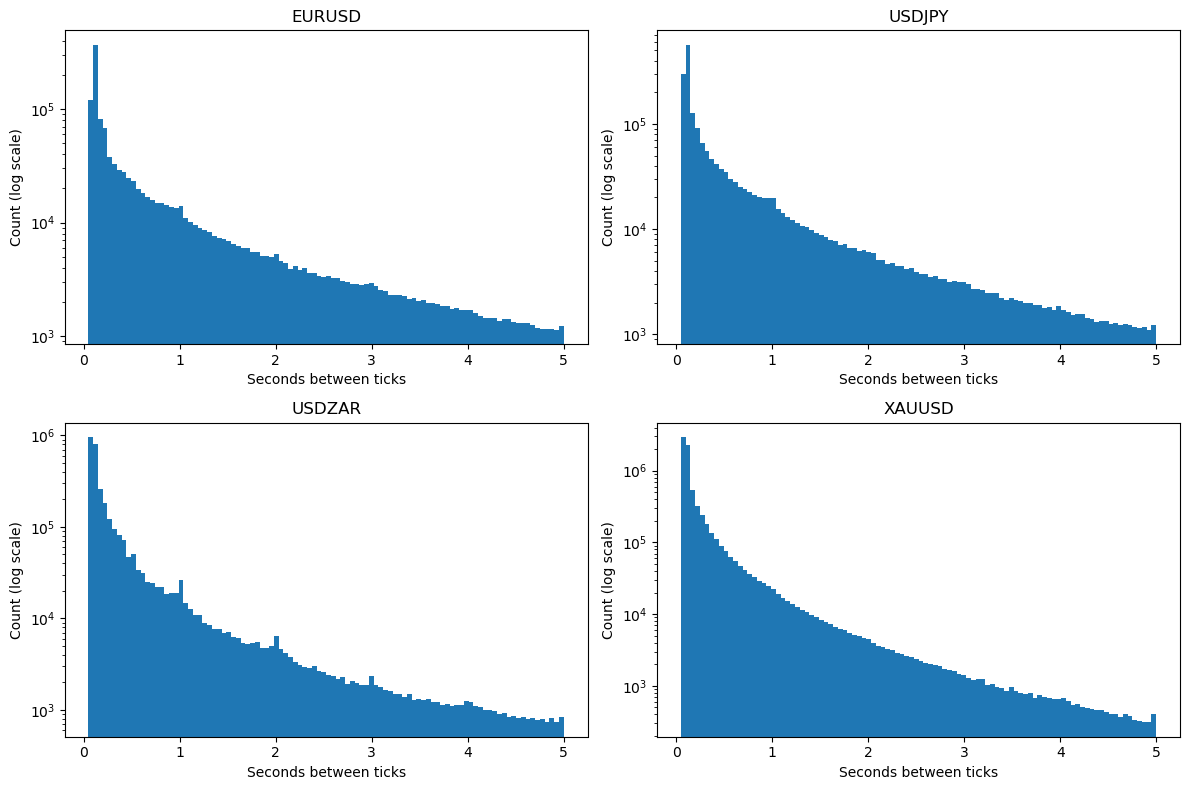

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, df) in zip(axes, data.items()):
    
    dt = df.index.to_series().diff().dt.total_seconds()
    dt = dt[dt < 5]
    
    ax.hist(dt, bins=100)
    ax.set_yscale("log")
    ax.set_title(name)
    ax.set_xlabel("Seconds between ticks")
    ax.set_ylabel("Count (log scale)")

plt.tight_layout()
plt.show()

Spread analyse

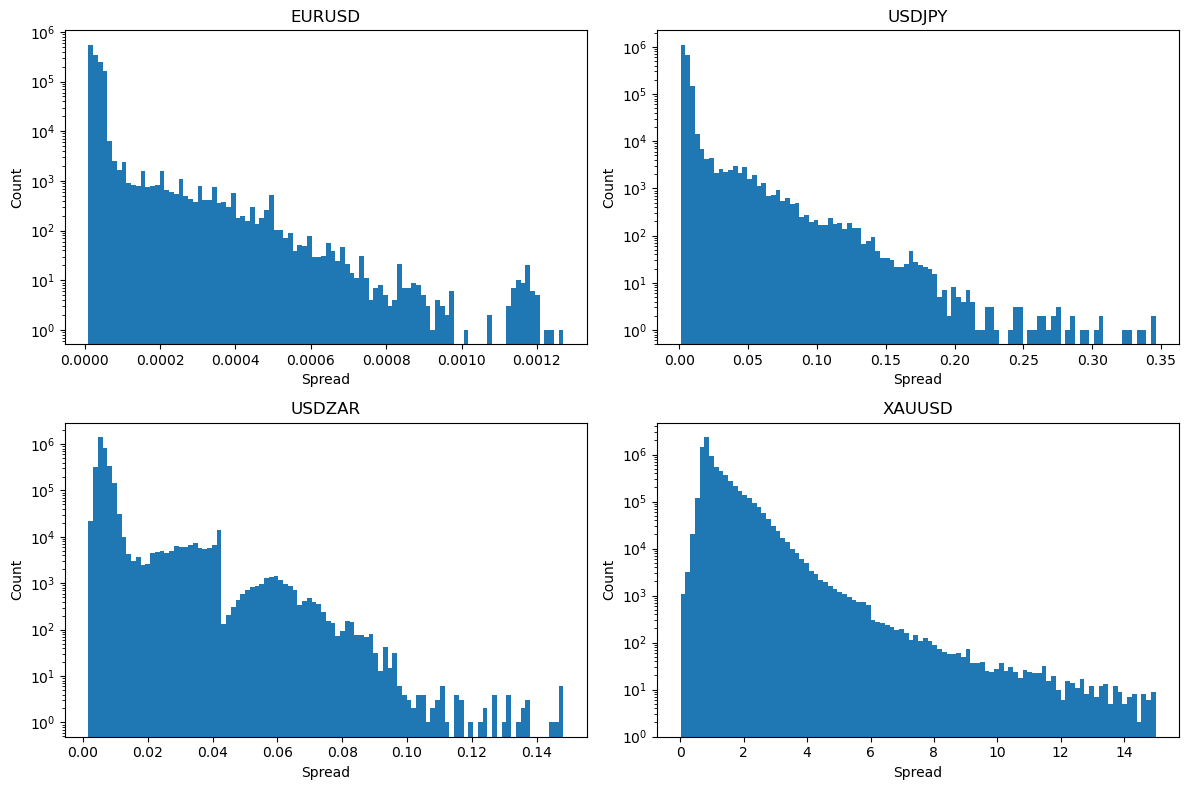

In [5]:
for df in data.values():
    df["spread"] = df["ask"] - df["bid"]

fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes = axes.flatten()

for ax, (name, df) in zip(axes, data.items()):
    
    spread = df["spread"]
    
    ax.hist(spread, bins=100)
    ax.set_title(name)
    ax.set_xlabel("Spread")
    ax.set_ylabel("Count")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()

SPREAD gjennom en dag

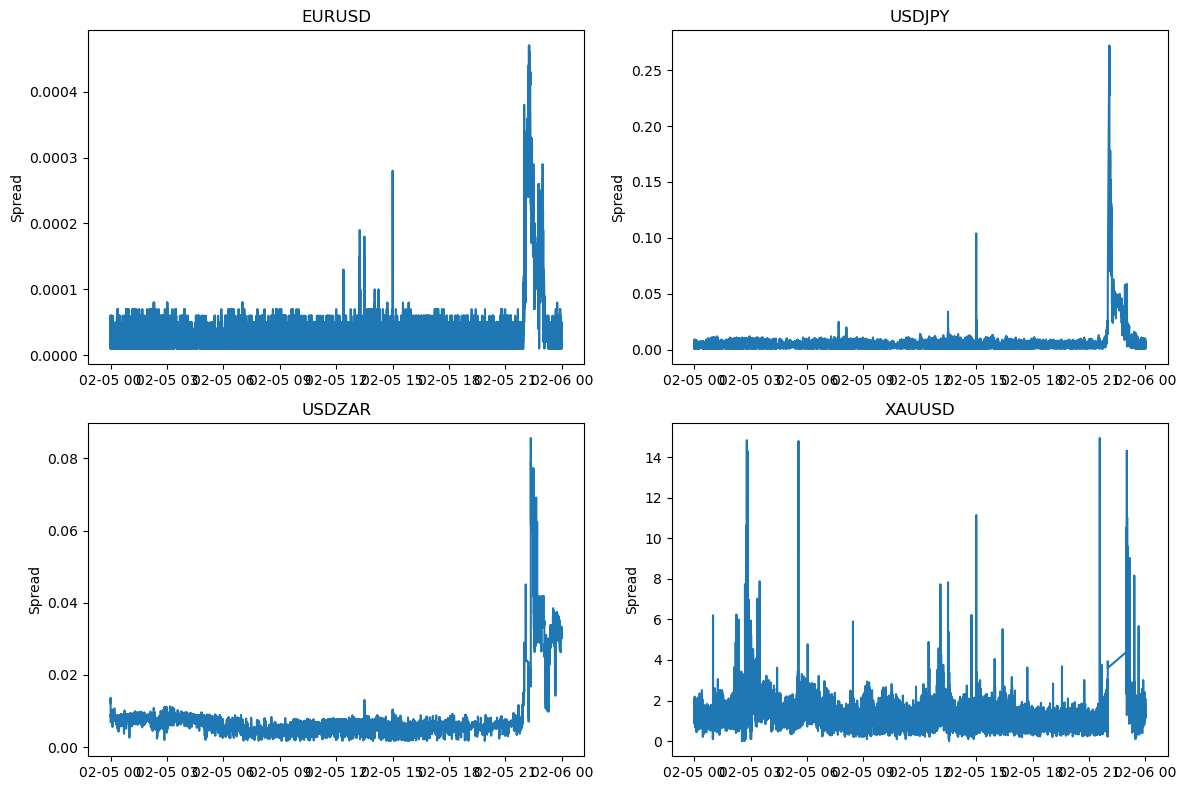

In [6]:
day = "2026-02-05"
fig, axes = plt.subplots(2,2, figsize=(12,8))
axes = axes.flatten()

for ax, (name, df) in zip(axes, data.items()):
    
    d = df.loc[day]
    
    ax.plot(d.index, d["spread"])
    ax.set_title(name)
    ax.set_ylabel("Spread")

plt.tight_layout()
plt.show()

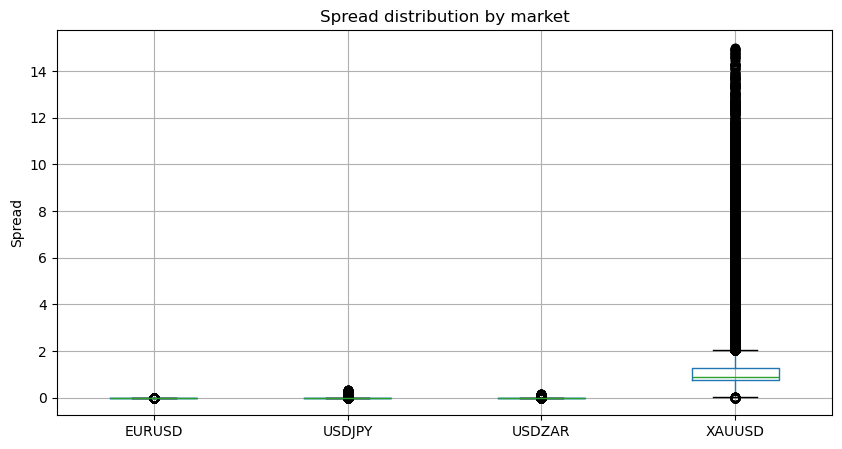

In [7]:


spread_df = pd.DataFrame({
    name: df["spread"] for name, df in data.items()
})

spread_df.boxplot(figsize=(10,5))

plt.ylabel("Spread")
plt.title("Spread distribution by market")
plt.show()

In [8]:
for name, df in data.items():
    df = pre_avg(df, k=1)
    df = compute_returns(df)
    data[name] = df
    
print(data["EURUSD"].head())

                                      bid      ask  volume  mid_price  \
datetime                                                                
2026-02-01 22:00:01.866000+00:00  1.18497  1.18543       0   1.185200   
2026-02-01 22:00:06.535000+00:00  1.18499  1.18544       0   1.185215   
2026-02-01 22:00:10.246000+00:00  1.18499  1.18539       0   1.185190   
2026-02-01 22:00:48.466000+00:00  1.18499  1.18537       0   1.185180   
2026-02-01 22:00:48.618000+00:00  1.18530  1.18534       0   1.185320   

                                   spread   pre_avg         r  
datetime                                                       
2026-02-01 22:00:01.866000+00:00  0.00046  1.185200  0.000005  
2026-02-01 22:00:06.535000+00:00  0.00045  1.185215  0.000015  
2026-02-01 22:00:10.246000+00:00  0.00040  1.185190 -0.000025  
2026-02-01 22:00:48.466000+00:00  0.00038  1.185180 -0.000010  
2026-02-01 22:00:48.618000+00:00  0.00004  1.185320  0.000140  


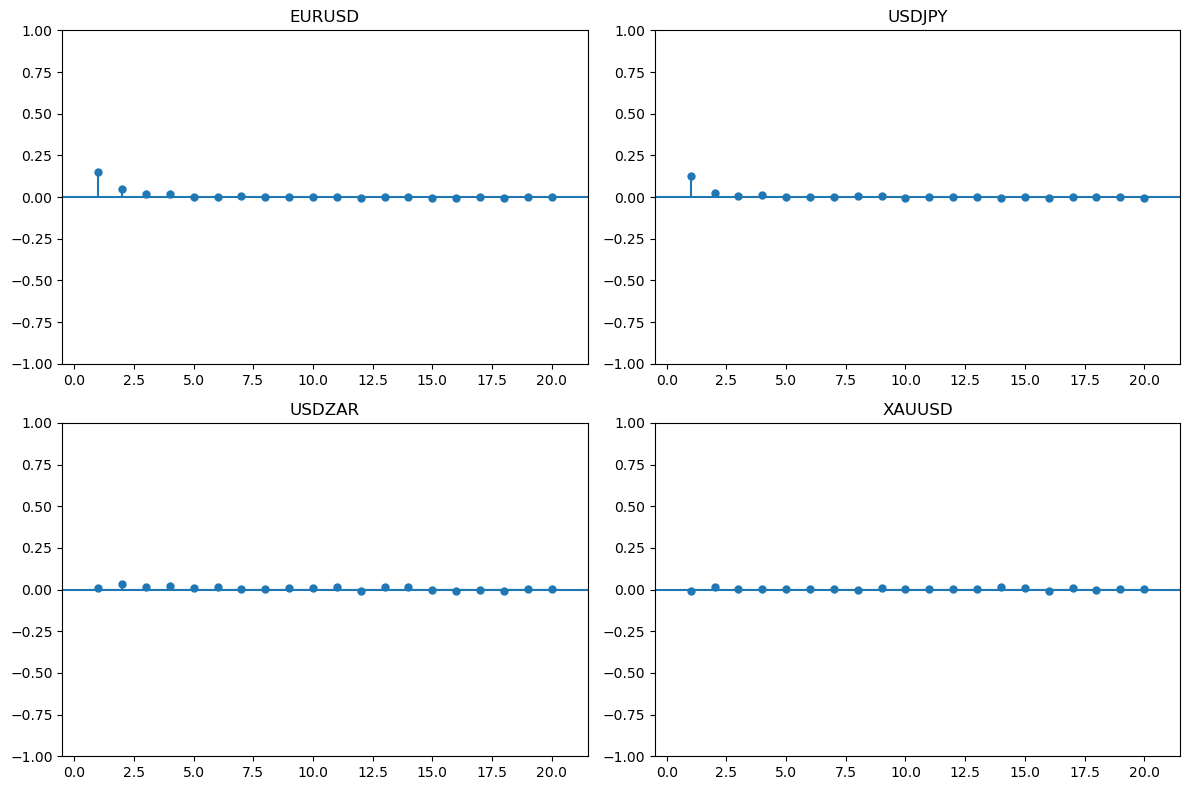

In [9]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,2, figsize=(12,8))
axes = axes.flatten()

for ax, (name, df) in zip(axes, data.items()):
    
    r = df["r"].dropna().iloc[:200000]  # sample for speed
    
    sm.graphics.tsa.plot_acf(r, lags=20, ax=ax, zero=False)
    
    ax.set_title(name)
    # ax.set_ylim(-0.5, 0.5)

plt.tight_layout()
plt.show()